<a href="https://colab.research.google.com/github/evucelic/Diplomski-Projekt/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Main questions
1. What exactly changes across regimes
2. Are Deep Models actually necessary and better than benchmarks
3. How to handle temporal dependencies
4. How many regimes actually exist in the data

TODO ADD factors to the dataset

In [3]:
data = pd.read_csv(
    "/content/drive/MyDrive/data_dipl_proj/merged_100_portfolios_ff5_daily.csv",
    parse_dates=True,
    low_memory=False
)
data = data.set_index("Date")
data.head()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,SMALL HiBM,...,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,,,,,,,,,,,,,,,,
1963-07-01,-0.20,0.28,-0.44,-1.65,-0.15,-0.93,0.09,-0.93,-0.75,-0.84,...,-0.22,-1.01,-1.35,-0.35,-0.67,0.00,-0.34,-0.01,0.16,0.01
1963-07-02,-0.23,0.93,-0.27,0.69,0.40,0.29,0.44,0.46,0.20,0.68,...,0.47,1.02,1.77,0.00,0.79,-0.26,0.26,-0.07,-0.20,0.01
1963-07-03,0.54,0.79,0.87,0.59,1.15,0.38,0.43,0.30,-0.24,0.65,...,1.05,0.20,0.06,0.35,0.63,-0.17,-0.09,0.18,-0.34,0.01
1963-07-05,1.75,-0.89,0.02,-0.30,0.63,0.57,0.05,-0.11,0.93,0.24,...,-0.02,-0.04,0.42,0.00,0.40,0.08,-0.27,0.09,-0.34,0.01
1963-07-08,1.06,-1.26,-1.33,0.25,0.28,-1.22,-0.96,-0.14,-0.86,-0.96,...,-0.17,-1.52,-0.91,-1.38,-0.63,0.04,-0.18,-0.29,0.14,0.01


In [4]:
data = data.replace(r'^\s*$', np.nan, regex=True)

data = data.replace({
    '-99.99': np.nan,
    '-999': np.nan,
    '-999.0': np.nan,
    '-999.00': np.nan,
    -99.99: np.nan,
    -999: np.nan,
    -999.0: np.nan,
    -100: np.nan,
    -100.0: np.nan,
    -100.00: np.nan
})

data = data.apply(lambda col: pd.to_numeric(col, errors='coerce'))
data = data / 100
data.index = pd.to_datetime(data.index, format="%Y-%m-%d")

# main analysis, with nans which we will marginalize
data_with_nans = data.astype(np.float32)
data_nan_mask = data_with_nans.notna().astype(np.float32)
# baseline, zero filled the nans
data_zero_filled = data_with_nans.fillna(0.0)

In [5]:
factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
portfolio_cols = [c for c in data_with_nans.columns if c not in factor_cols]

port = data_with_nans[portfolio_cols]
factors = data_with_nans[factor_cols]

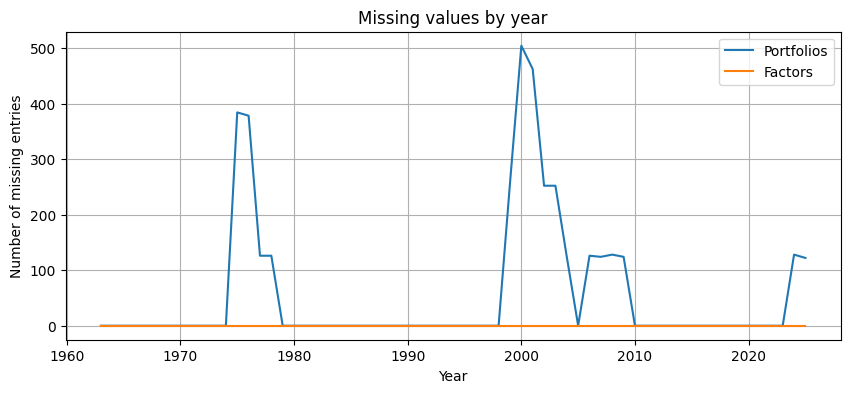

In [6]:
missing_port_by_year = port.isna().groupby(port.index.year).sum().sum(axis=1)
missing_factor_by_year = factors.isna().groupby(factors.index.year).sum().sum(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(missing_port_by_year.index, missing_port_by_year, label="Portfolios")
plt.plot(missing_factor_by_year.index, missing_factor_by_year, label="Factors")
plt.title("Missing values by year")
plt.xlabel("Year")
plt.ylabel("Number of missing entries")
plt.legend()
plt.grid(True)
plt.show()

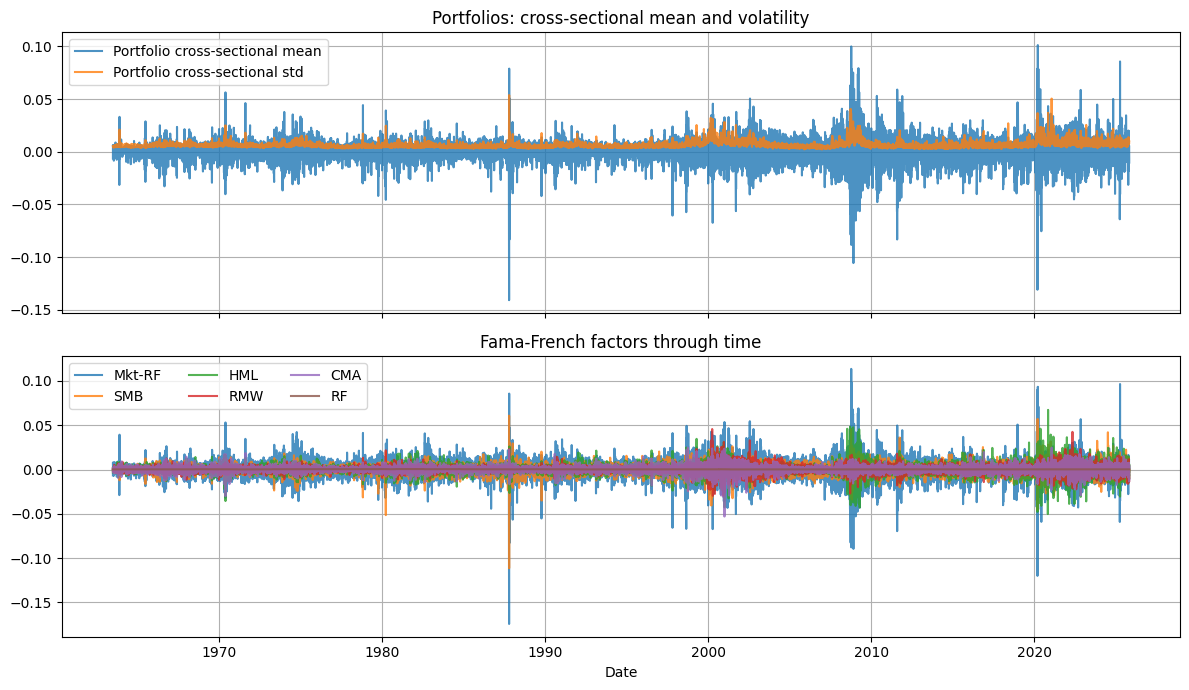

In [7]:
cs_mean = port.mean(axis=1)
cs_std = port.std(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(cs_mean.index, cs_mean, label="Portfolio cross-sectional mean", alpha=0.8)
axes[0].plot(cs_std.index, cs_std, label="Portfolio cross-sectional std", alpha=0.8)
axes[0].set_title("Portfolios: cross-sectional mean and volatility")
axes[0].legend()
axes[0].grid(True)

for col in factor_cols:
    axes[1].plot(factors.index, factors[col], label=col, alpha=0.8)

axes[1].set_title("Fama-French factors through time")
axes[1].set_xlabel("Date")
axes[1].legend(ncol=3)
axes[1].grid(True)

plt.tight_layout()
plt.show()

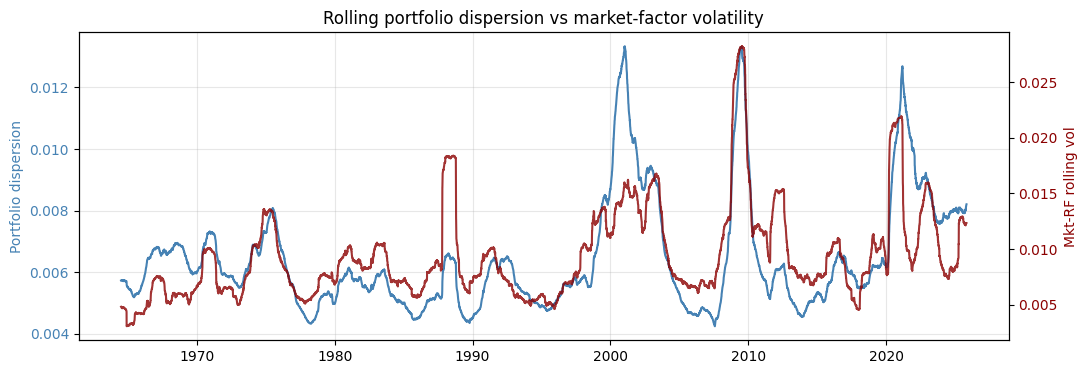

In [8]:
portfolio_dispersion = port.std(axis=1).rolling(252).mean()
mkt_vol = factors["Mkt-RF"].rolling(252).std()

fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.plot(portfolio_dispersion.index, portfolio_dispersion, color="steelblue", label="Portfolio cross-sectional vol")
ax1.set_ylabel("Portfolio dispersion", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(mkt_vol.index, mkt_vol, color="darkred", alpha=0.8, label="Mkt-RF rolling vol")
ax2.set_ylabel("Mkt-RF rolling vol", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

plt.title("Rolling portfolio dispersion vs market-factor volatility")
plt.xlabel("Date")
plt.show()

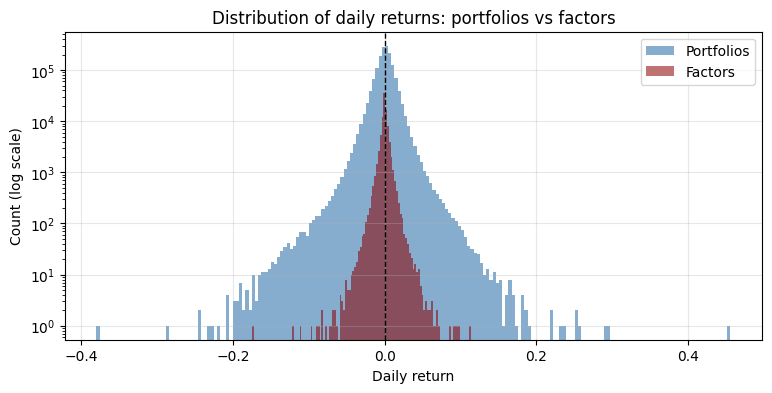

In [9]:
x_port = port.to_numpy().ravel()
x_port = x_port[~np.isnan(x_port)]

x_fact = factors.to_numpy().ravel()
x_fact = x_fact[~np.isnan(x_fact)]

plt.figure(figsize=(9, 4))
plt.hist(x_port, bins=200, log=True, alpha=0.65, label="Portfolios", color="steelblue")
plt.hist(x_fact, bins=120, log=True, alpha=0.55, label="Factors", color="darkred")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of daily returns: portfolios vs factors")
plt.xlabel("Daily return")
plt.ylabel("Count (log scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


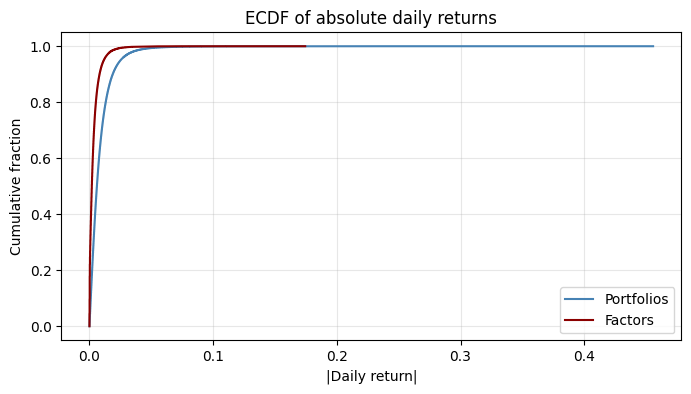

In [10]:
abs_port = np.sort(np.abs(x_port))
abs_fact = np.sort(np.abs(x_fact))

y_port = np.arange(1, len(abs_port) + 1) / len(abs_port)
y_fact = np.arange(1, len(abs_fact) + 1) / len(abs_fact)

plt.figure(figsize=(8, 4))
plt.plot(abs_port, y_port, label="Portfolios", color="steelblue")
plt.plot(abs_fact, y_fact, label="Factors", color="darkred")
plt.title("ECDF of absolute daily returns")
plt.xlabel("|Daily return|")
plt.ylabel("Cumulative fraction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

splitting, scaling data

In [11]:
def chronological_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train = df.iloc[:train_end].copy()
    val = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()

    return train, val, test


full_nan_train, full_nan_val, full_nan_test = chronological_split(data_with_nans)
full_zero_train, full_zero_val, full_zero_test = chronological_split(data_zero_filled)
full_mask_train, full_mask_val, full_mask_test = chronological_split(data_nan_mask)


print(full_nan_train.index.min(), full_nan_train.index.max(), full_nan_train.shape)
print(full_nan_val.index.min(), full_nan_val.index.max(), full_nan_val.shape)
print(full_nan_test.index.min(), full_nan_test.index.max(), full_nan_test.shape)

1963-07-01 00:00:00 2007-02-16 00:00:00 (10983, 106)
2007-02-20 00:00:00 2016-06-22 00:00:00 (2353, 106)
2016-06-23 00:00:00 2025-10-31 00:00:00 (2354, 106)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler_zero = StandardScaler()

zero_train_scaled = pd.DataFrame(
    scaler_zero.fit_transform(full_zero_train),
    index=full_zero_train.index,
    columns=full_zero_train.columns
)

zero_val_scaled = pd.DataFrame(
    scaler_zero.transform(full_zero_val),
    index=full_zero_val.index,
    columns=full_zero_val.columns
)

zero_test_scaled = pd.DataFrame(
    scaler_zero.transform(full_zero_test),
    index=full_zero_test.index,
    columns=full_zero_test.columns
)


In [14]:
scaler_masked = StandardScaler()

nan_train_scaled = pd.DataFrame(
    scaler_masked.fit_transform(full_nan_train),
    index=full_nan_train.index,
    columns=full_nan_train.columns
)

nan_val_scaled = pd.DataFrame(
    scaler_masked.transform(full_nan_val),
    index=full_nan_val.index,
    columns=full_nan_val.columns
)

nan_test_scaled = pd.DataFrame(
    scaler_masked.transform(full_nan_test),
    index=full_nan_test.index,
    columns=full_nan_test.columns
)

mask_train = full_mask_train.copy()
mask_val = full_mask_val.copy()
mask_test = full_mask_test.copy()

# storage version for torch later
nan_train_filled = nan_train_scaled.fillna(0.0)
nan_val_filled = nan_val_scaled.fillna(0.0)
nan_test_filled = nan_test_scaled.fillna(0.0)

In [15]:
datasets = {
    "masked_full": {
        "train": nan_train_filled.astype(np.float32),
        "val": nan_val_filled.astype(np.float32),
        "test": nan_test_filled.astype(np.float32),
        "mask_train": mask_train.astype(np.float32),
        "mask_val": mask_val.astype(np.float32),
        "mask_test": mask_test.astype(np.float32),
        "raw_train": nan_train_scaled.astype(np.float32),
        "raw_val": nan_val_scaled.astype(np.float32),
        "raw_test": nan_test_scaled.astype(np.float32),
    },
}

In [16]:
for name, ds in datasets.items():
    print(f"\n{name}")
    print("train:", ds["train"].shape)
    print("val:  ", ds["val"].shape)
    print("test: ", ds["test"].shape)

    if ds["mask_train"] is not None:
        print("train observed fraction:", ds["mask_train"].to_numpy().mean())
        print("val observed fraction:  ", ds["mask_val"].to_numpy().mean())
        print("test observed fraction: ", ds["mask_test"].to_numpy().mean())


zero_full
train: (10983, 106)
val:   (2353, 106)
test:  (2354, 106)

masked_full
train: (10983, 106)
val:   (2353, 106)
test:  (2354, 106)
train observed fraction: 0.9974042
val observed fraction:   0.9986208
test observed fraction:  0.9989981


Podaci od 02.07.1945 - 31.10.2025. Podaci koji nedostaju su zamijenjeni s 0 (stacionarni trenutci)

Portfelji su formirani na temelju 2 karakteristike, size(market equity) i value (Book-to-market)

Napomena za size:
"A fundamental problem in handling accounting data is the look-ahead bias; we must not include data in forming a portfolio that was not available knowledge at the time. Of course, researchers have more information when looking into the past than agents actually had at that moment. However, abnormal excess returns from a trading strategy should not rely on an information advantage because the differential cannot be the result of informed agents’ trades. Hence, we have to lag accounting information.

We continue to lag market capitalization and firm size by one month" source: https://www.tidy-finance.org/r/value-and-bivariate-sorts.html



Kako su točno formirani portfelji?
U danom trenutku t, uzimamo cijeli universe dionica u tom trenutku i pridružimo im dvije karakteristike npr. size i value.
Recimo da svakoj dionici pridružimo size od 1-10 i value od 1-10. Vrijednosti 1-10 predstavljaju decile veličine/value s NYSE burze, računaju se jednom godišnje te su stacionarni godinu dana.

Grupiramo dionice na temelju labela i formiramo 10x10 = 100 portfelja u svakom trenutku, weightanih proporcionalno market capu (lagganom 1mj).

Ignore deep models for now

implement a HMM model with a factor regression component

In [40]:
train_df = datasets["masked_full"]["train"]
train_mask_df = datasets["masked_full"]["mask_train"]

portfolio_returns = train_df[portfolio_cols].to_numpy(dtype=np.float64)
factor_returns = train_df[factor_cols].to_numpy(dtype=np.float64)
observed_mask = train_mask_df[portfolio_cols].to_numpy(dtype=bool)

valid_dates = np.all(np.isfinite(factor_returns), axis=1)
portfolio_returns = portfolio_returns[valid_dates]
factor_returns = factor_returns[valid_dates]
observed_mask = observed_mask[valid_dates]
plot_index = train_df.index[valid_dates]

num_dates, num_portfolios = portfolio_returns.shape
num_factors = factor_returns.shape[1]

design_matrix = np.column_stack([np.ones(num_dates), factor_returns])

In [41]:
def compute_log_emission_density(
    portfolio_returns,
    factor_returns,
    observed_mask,
    state_intercepts,
    state_factor_loadings,
    residual_std,
):
    num_dates = portfolio_returns.shape[0]
    num_states = state_intercepts.shape[0]

    residual_var = np.maximum(residual_std ** 2, 1e-8)
    log_emission_density = np.zeros((num_dates, num_states))

    for state in range(num_states):
        predicted_returns = state_intercepts[state][None, :] + factor_returns @ state_factor_loadings[state].T
        squared_error = (portfolio_returns - predicted_returns) ** 2

        asset_log_density = -0.5 * (
            np.log(2.0 * np.pi * residual_var)[None, :] +
            squared_error / residual_var[None, :]
        )

        asset_log_density[~observed_mask] = 0.0
        log_emission_density[:, state] = asset_log_density.sum(axis=1)

    return log_emission_density


def e_step_forward_backward(log_emission_density, initial_state_probs, transition_probs):
    num_dates, num_states = log_emission_density.shape

    log_initial = np.log(np.clip(initial_state_probs, 1e-12, 1.0))
    log_transition = np.log(np.clip(transition_probs, 1e-12, 1.0))

    forward_log_prob = np.zeros((num_dates, num_states))
    forward_log_prob[0] = log_initial + log_emission_density[0]

    for t in range(1, num_dates):
        forward_log_prob[t] = log_emission_density[t] + logsumexp(
            forward_log_prob[t - 1][:, None] + log_transition,
            axis=0
        )

    total_log_likelihood = logsumexp(forward_log_prob[-1])

    backward_log_prob = np.zeros((num_dates, num_states))
    for t in range(num_dates - 2, -1, -1):
        backward_log_prob[t] = logsumexp(
            log_transition + log_emission_density[t + 1][None, :] + backward_log_prob[t + 1][None, :],
            axis=1
        )

    log_state_posterior = forward_log_prob + backward_log_prob
    log_state_posterior -= logsumexp(log_state_posterior, axis=1, keepdims=True)
    state_posterior = np.exp(log_state_posterior)

    transition_posterior = np.zeros((num_dates - 1, num_states, num_states))
    for t in range(num_dates - 1):
        log_pair_posterior = (
            forward_log_prob[t][:, None]
            + log_transition
            + log_emission_density[t + 1][None, :]
            + backward_log_prob[t + 1][None, :]
        )
        log_pair_posterior -= logsumexp(log_pair_posterior)
        transition_posterior[t] = np.exp(log_pair_posterior)

    return state_posterior, transition_posterior, total_log_likelihood

In [42]:
def update_state_regressions(
    portfolio_returns,
    design_matrix,
    observed_mask,
    state_posterior,
    num_states,
    num_portfolios,
    num_factors,
    ridge=1e-6,
):
    state_intercepts = np.zeros((num_states, num_portfolios))
    state_factor_loadings = np.zeros((num_states, num_portfolios, num_factors))

    for state in range(num_states):
        sqrt_weights = np.sqrt(np.clip(state_posterior[:, state], 1e-12, None))

        for asset in range(num_portfolios):
            observed = observed_mask[:, asset]
            if observed.sum() < (num_factors + 1):
                continue

            weighted_X = design_matrix[observed] * sqrt_weights[observed, None]
            weighted_y = portfolio_returns[observed, asset] * sqrt_weights[observed]

            coeffs = np.linalg.solve(
                weighted_X.T @ weighted_X + ridge * np.eye(num_factors + 1),
                weighted_X.T @ weighted_y
            )

            state_intercepts[state, asset] = coeffs[0]
            state_factor_loadings[state, asset] = coeffs[1:]

    return state_intercepts, state_factor_loadings


def update_residual_std(
    portfolio_returns,
    factor_returns,
    observed_mask,
    state_posterior,
    state_intercepts,
    state_factor_loadings,
):
    num_dates, num_portfolios = portfolio_returns.shape
    num_states = state_posterior.shape[1]

    weighted_sse = np.zeros(num_portfolios)
    observed_counts = np.maximum(observed_mask.sum(axis=0), 1)

    for state in range(num_states):
        predicted_returns = state_intercepts[state][None, :] + factor_returns @ state_factor_loadings[state].T
        squared_error = (portfolio_returns - predicted_returns) ** 2
        squared_error[~observed_mask] = 0.0
        weighted_sse += (state_posterior[:, state][:, None] * squared_error).sum(axis=0)

    residual_std = np.sqrt(np.maximum(weighted_sse / observed_counts, 1e-8))
    return residual_std

In [51]:
def update_markov_parameters(state_posterior, transition_posterior, sticky_strength=50.0):
    initial_state_probs = np.clip(state_posterior[0], 1e-12, None)
    initial_state_probs = initial_state_probs / initial_state_probs.sum()

    num_states = state_posterior.shape[1]
    transition_counts = transition_posterior.sum(axis=0)

    transition_counts += sticky_strength * np.eye(num_states)

    transition_probs = np.clip(transition_counts, 1e-12, None)
    transition_probs = transition_probs / transition_probs.sum(axis=1, keepdims=True)

    return initial_state_probs, transition_probs

In [44]:
def run_model_once(
    portfolio_returns,
    factor_returns,
    observed_mask,
    design_matrix,
    num_states=3,
    max_iterations=50,
    tolerance=1e-4,
    ridge=1e-6,
    seed=42,
    sticky_strength=0.0,
):
    num_dates, num_portfolios = portfolio_returns.shape
    num_factors = factor_returns.shape[1]

    initial_state_probs = np.full(num_states, 1.0 / num_states)

    transition_probs = np.full((num_states, num_states), 0.05 / (num_states - 1))
    np.fill_diagonal(transition_probs, 0.95)

    rng = np.random.default_rng(seed)
    state_posterior = rng.dirichlet(np.ones(num_states), size=num_dates)

    state_intercepts, state_factor_loadings = update_state_regressions(
        portfolio_returns,
        design_matrix,
        observed_mask,
        state_posterior,
        num_states,
        num_portfolios,
        num_factors,
        ridge=ridge,
    )

    residual_std = update_residual_std(
        portfolio_returns,
        factor_returns,
        observed_mask,
        state_posterior,
        state_intercepts,
        state_factor_loadings,
    )

    log_likelihood_history = []
    previous_log_likelihood = -np.inf

    for iteration in range(max_iterations):
        log_emission_density = compute_log_emission_density(
            portfolio_returns,
            factor_returns,
            observed_mask,
            state_intercepts,
            state_factor_loadings,
            residual_std,
        )

        state_posterior, transition_posterior, total_log_likelihood = e_step_forward_backward(
            log_emission_density,
            initial_state_probs,
            transition_probs,
        )

        initial_state_probs, transition_probs = update_markov_parameters(
            state_posterior,
            transition_posterior,
            sticky_strength=sticky_strength,
        )

        state_intercepts, state_factor_loadings = update_state_regressions(
            portfolio_returns,
            design_matrix,
            observed_mask,
            state_posterior,
            num_states,
            num_portfolios,
            num_factors,
            ridge=ridge,
        )

        residual_std = update_residual_std(
            portfolio_returns,
            factor_returns,
            observed_mask,
            state_posterior,
            state_intercepts,
            state_factor_loadings,
        )

        log_likelihood_history.append(total_log_likelihood)

        if iteration > 0 and abs(total_log_likelihood - previous_log_likelihood) < tolerance:
            break

        previous_log_likelihood = total_log_likelihood

    most_likely_state = state_posterior.argmax(axis=1)

    return {
        "log_likelihood": log_likelihood_history[-1],
        "initial_state_probs": initial_state_probs,
        "transition_probs": transition_probs,
        "state_posterior": state_posterior,
        "most_likely_state": most_likely_state,
        "state_intercepts": state_intercepts,
        "state_factor_loadings": state_factor_loadings,
        "residual_std": residual_std,
        "history": log_likelihood_history,
        "num_states": num_states,
        "num_dates": num_dates,
        "num_portfolios": num_portfolios,
        "num_factors": num_factors,
    }

In [45]:
def count_params(num_states, num_portfolios, num_factors):
    return (
        (num_states - 1) +
        num_states * (num_states - 1) +
        num_states * num_portfolios * (1 + num_factors) +
        num_portfolios
    )


def compute_bic(log_likelihood, num_params, num_dates):
    return -2 * log_likelihood + num_params * np.log(num_dates)

In [53]:
results = []
best_models = {}

for num_states in [2,3]:
    best_model = None
    best_log_likelihood = -np.inf
    best_seed = None

    for seed in range(5):
        model = run_model_once(
            portfolio_returns=portfolio_returns,
            factor_returns=factor_returns,
            observed_mask=observed_mask,
            design_matrix=design_matrix,
            num_states=num_states,
            max_iterations=50,
            tolerance=1e-4,
            ridge=1e-5,
            seed=seed,
            sticky_strength=50.0,
        )

        if model["log_likelihood"] > best_log_likelihood:
            best_log_likelihood = model["log_likelihood"]
            best_model = model
            best_seed = seed

    bic = compute_bic(
        log_likelihood=best_model["log_likelihood"],
        num_params=count_params(
            best_model["num_states"],
            best_model["num_portfolios"],
            best_model["num_factors"],
        ),
        num_dates=best_model["num_dates"],
    )

    results.append({
        "num_states": num_states,
        "best_seed": best_seed,
        "log_likelihood": best_model["log_likelihood"],
        "bic": bic,
    })

    best_models[num_states] = best_model

results_df = pd.DataFrame(results).sort_values("bic").reset_index(drop=True)
display(results_df)

,num_states,best_seed,log_likelihood,bic
0,3,2,-864559.047131,1.749662e+06
1,2,2,-873838.332183,1.761661e+06


In [54]:
best_num_states = int(results_df.iloc[0]["num_states"])
best_model = best_models[best_num_states]
print("Best K:", best_num_states)
print("Best BIC:", results_df.iloc[0]["bic"])

Best K: 3
Best BIC: 1749661.555676437


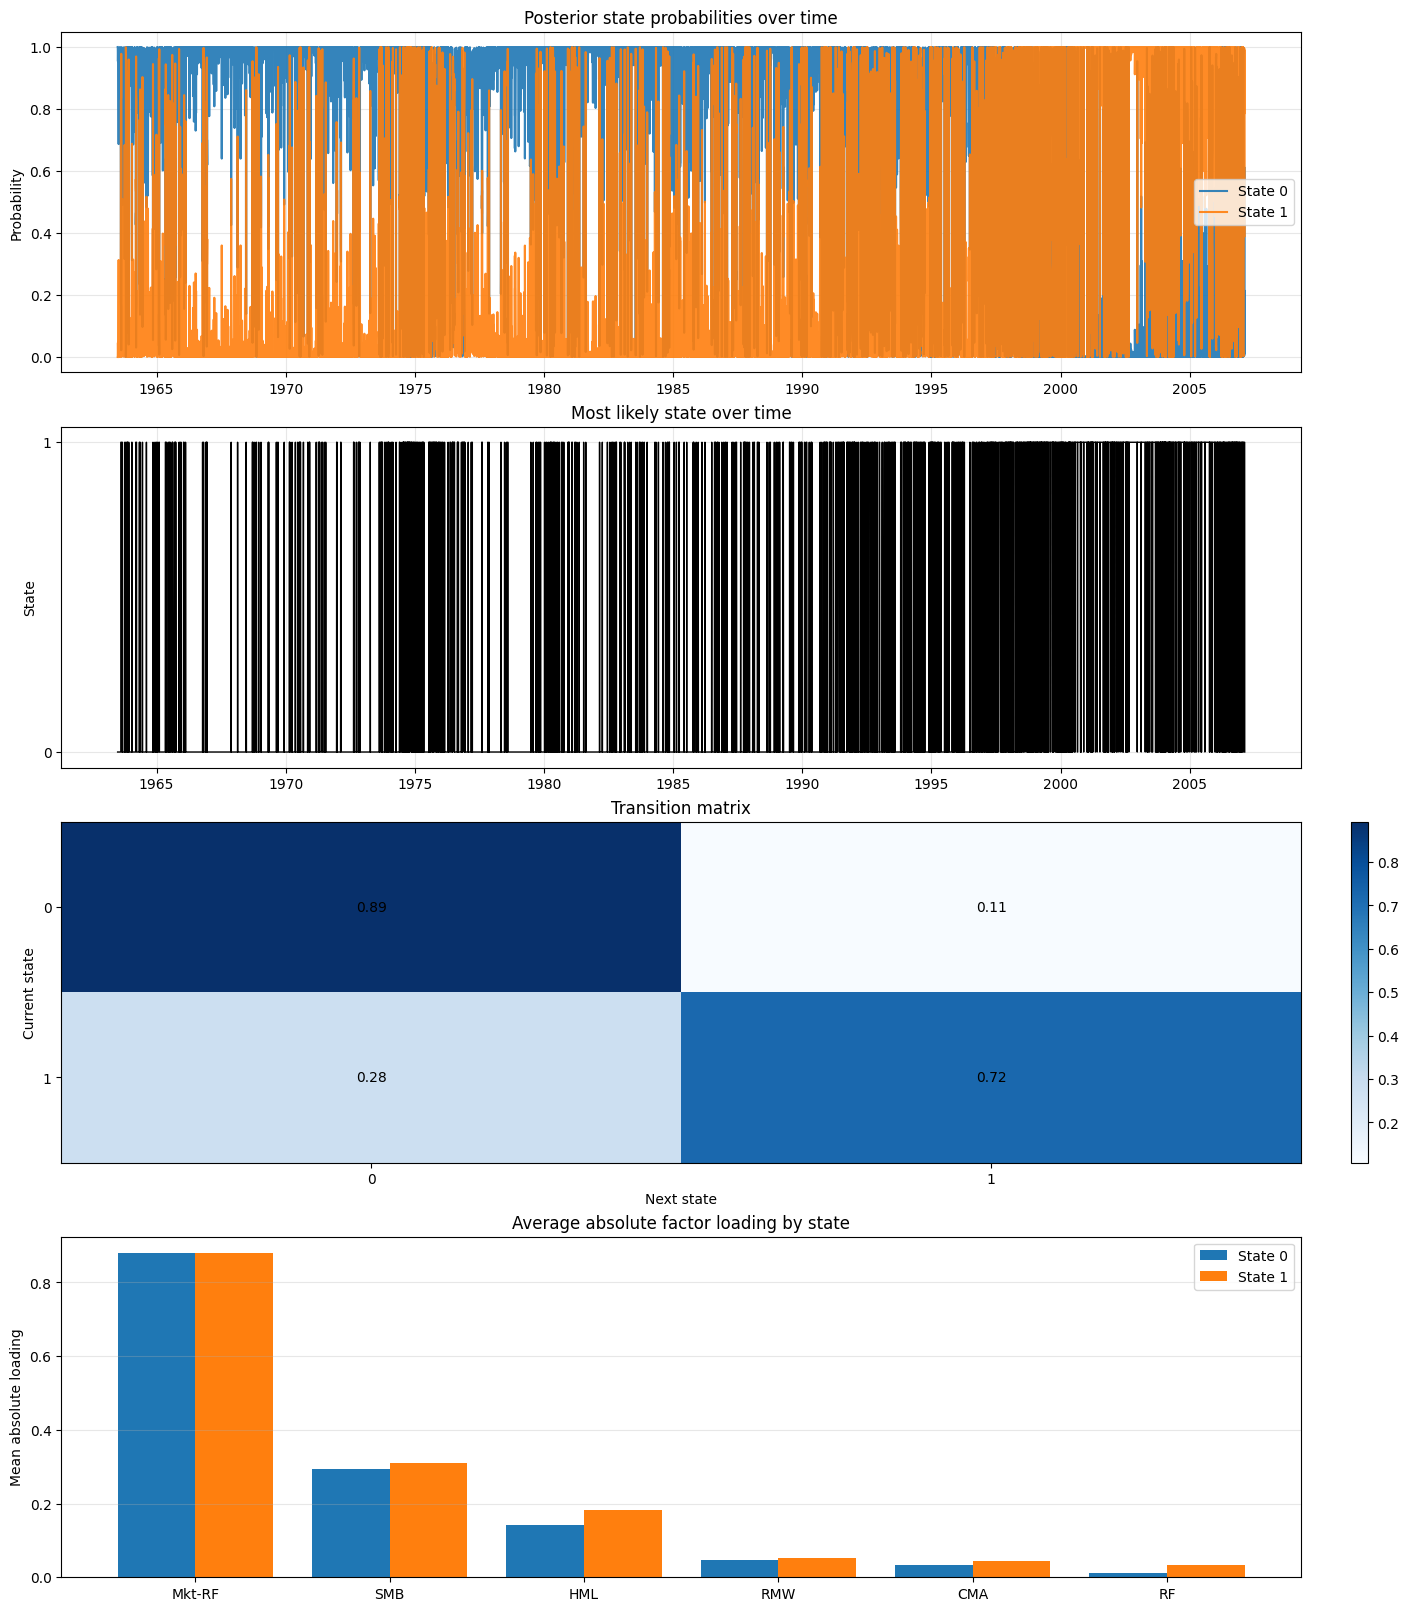

In [57]:
best_model = best_models[2]
state_posterior = best_model["state_posterior"]
most_likely_state = best_model["most_likely_state"]
transition_probs = best_model["transition_probs"]
state_factor_loadings = best_model["state_factor_loadings"]
num_states = best_model["num_states"]

fig, axes = plt.subplots(4, 1, figsize=(14, 16), constrained_layout=True)

for k in range(num_states):
    axes[0].plot(plot_index, state_posterior[:, k], label=f"State {k}", alpha=0.9)
axes[0].set_title("Posterior state probabilities over time")
axes[0].set_ylabel("Probability")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_index, most_likely_state, color="black", linewidth=1)
axes[1].set_title("Most likely state over time")
axes[1].set_ylabel("State")
axes[1].set_yticks(range(num_states))
axes[1].grid(True, alpha=0.3)

im = axes[2].imshow(transition_probs, cmap="Blues", aspect="auto")
axes[2].set_title("Transition matrix")
axes[2].set_xlabel("Next state")
axes[2].set_ylabel("Current state")
axes[2].set_xticks(range(num_states))
axes[2].set_yticks(range(num_states))

for i in range(num_states):
    for j in range(num_states):
        axes[2].text(j, i, f"{transition_probs[i, j]:.2f}", ha="center", va="center", color="black")

plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

mean_abs_loading = np.mean(np.abs(state_factor_loadings), axis=1)
x = np.arange(len(factor_cols))
width = 0.8 / num_states

for k in range(num_states):
    axes[3].bar(x + k * width, mean_abs_loading[k], width=width, label=f"State {k}")

axes[3].set_title("Average absolute factor loading by state")
axes[3].set_xticks(x + width * (num_states - 1) / 2)
axes[3].set_xticklabels(factor_cols)
axes[3].set_ylabel("Mean absolute loading")
axes[3].legend()
axes[3].grid(True, axis="y", alpha=0.3)

plt.show()

In [58]:
posterior_confidence = state_posterior.max(axis=1).mean()
hard_switches = np.sum(most_likely_state[1:] != most_likely_state[:-1])
expected_durations = 1 / np.maximum(1 - np.diag(transition_probs), 1e-12)

print("Posterior confidence:", posterior_confidence)
print("Hard switches:", hard_switches)
print("Expected durations:", expected_durations)
print("State occupancy:", np.bincount(most_likely_state, minlength=num_states) / len(most_likely_state))

Posterior confidence: 0.9324519838754206
Hard switches: 1448
Expected durations: [9.30832126 3.61927065]
State occupancy: [0.74050806 0.25949194]


PCA + HMM combo

In [60]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.1 MB/s eta 0:00:00


Imputing missing data for portfolios...
PCA explained variance ratio (Top 5): 0.73

--- Correlation: PCA Factors vs Fama-French Factors ---
PCA Factor 1 correlates most with Mkt-RF (r = 0.93)
PCA Factor 2 correlates most with SMB (r = -0.91)
PCA Factor 3 correlates most with HML (r = -0.79)
PCA Factor 4 correlates most with SMB (r = -0.21)
PCA Factor 5 correlates most with RMW (r = -0.24)

Fitting 3-state sticky HMM...

--- Results ---
Train Log-Likelihood: -102948.99
Test Log-Likelihood: -29831.53
State distributions (Train): {np.int64(0): np.int64(3726), np.int64(1): np.int64(863), np.int64(2): np.int64(6394)}

Learned Transition Matrix (Should be mostly diagonal):
[[0.8   0.025 0.175]
 [0.11  0.89  0.   ]
 [0.112 0.    0.888]]
BIC: 206512.05


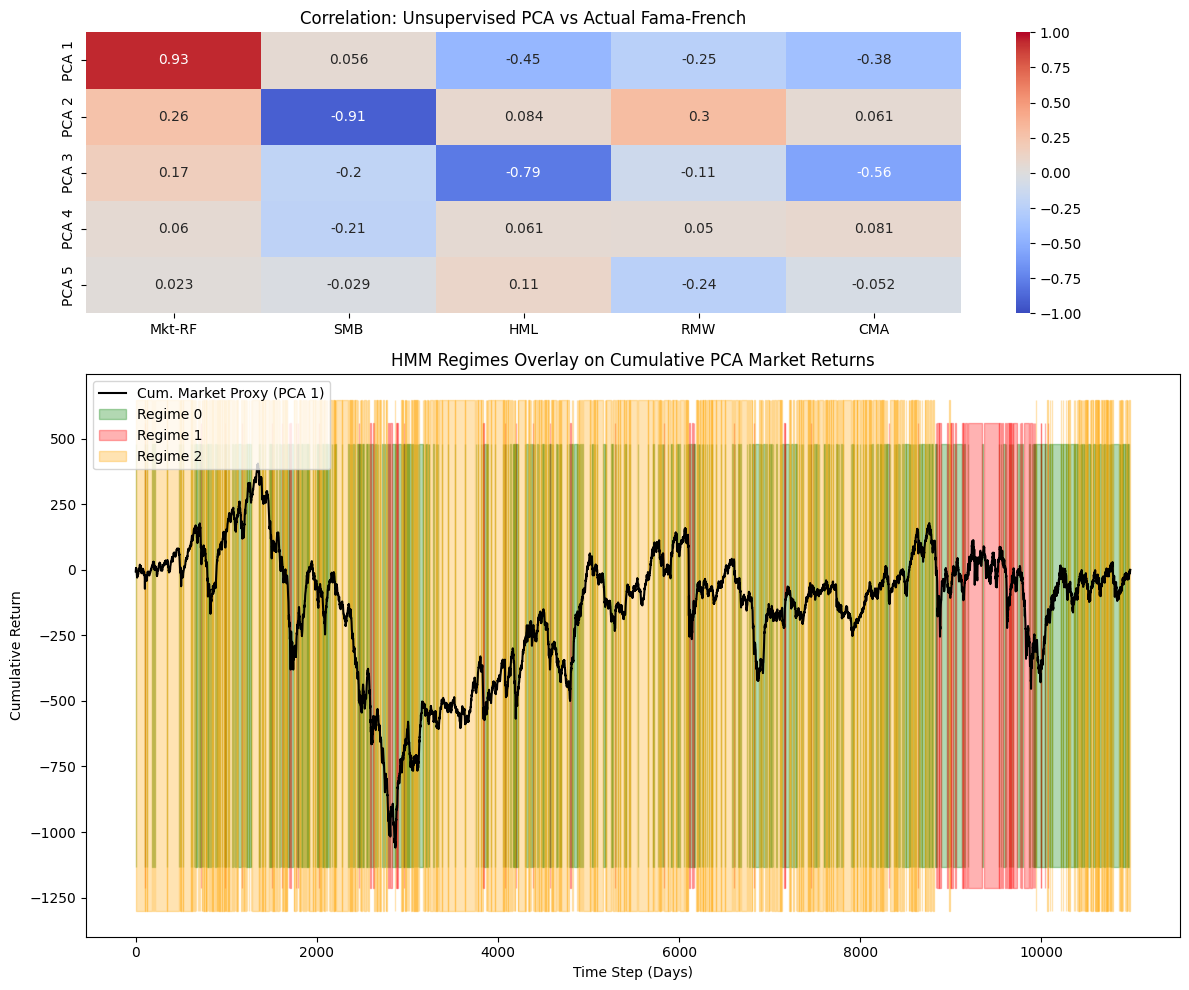

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from hmmlearn import hmm
from scipy.stats import pearsonr

# ==========================================
# 1. SETUP AND DATA PREP
# ==========================================
# Extract data from the datasets dictionary
raw_train = datasets["masked_full"]["raw_train"]
mask_train = datasets["masked_full"]["mask_train"]
raw_test = datasets["masked_full"]["raw_test"]
mask_test = datasets["masked_full"]["mask_test"]

# Define columns
factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
portfolio_cols = [c for c in data_with_nans.columns if c not in factor_cols]

# Apply masks (convert 0s in mask back to np.nan)
train_data = np.where(mask_train == 0, np.nan, raw_train)
test_data = np.where(mask_test == 0, np.nan, raw_test)

train_df = pd.DataFrame(train_data, columns=data_with_nans.columns)
test_df = pd.DataFrame(test_data, columns=data_with_nans.columns)

# Split out Portfolios vs Fama-French Factors
train_portfolios = train_df[portfolio_cols].values
test_portfolios = test_df[portfolio_cols].values
ff_factors_train = train_df[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].values

# ==========================================
# 2. IMPUTATION & PCA
# ==========================================
print("Imputing missing data for portfolios...")
imputer = IterativeImputer(max_iter=10, random_state=42)
train_portfolios_imputed = imputer.fit_transform(train_portfolios)
test_portfolios_imputed = imputer.transform(test_portfolios)

n_factors = 5
pca = PCA(n_components=n_factors, random_state=42)
train_pca_factors = pca.fit_transform(train_portfolios_imputed)
test_pca_factors = pca.transform(test_portfolios_imputed)

print(f"PCA explained variance ratio (Top {n_factors}): {pca.explained_variance_ratio_.sum():.2f}")

# ==========================================
# 3. FAMA-FRENCH CORRELATION CHECK
# ==========================================
print("\n--- Correlation: PCA Factors vs Fama-French Factors ---")
ff_names = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
corr_matrix = np.zeros((n_factors, len(ff_names)))

for i in range(n_factors):
    pca_f = train_pca_factors[:, i]
    correlations = [pearsonr(pca_f, ff_factors_train[:, j])[0] for j in range(len(ff_names))]
    best_match_idx = np.argmax(np.abs(correlations))
    print(f"PCA Factor {i+1} correlates most with {ff_names[best_match_idx]} (r = {correlations[best_match_idx]:.2f})")

    # Fill matrix for the heatmap later
    for j in range(len(ff_names)):
        corr_matrix[i, j] = pearsonr(pca_f, ff_factors_train[:, j])[0]

# ==========================================
# 4. STICKY REGIME SWITCHING (HMM)
# ==========================================
n_states = 3

# Compute global covariance to use as a regularizing prior
global_cov = np.cov(train_pca_factors.T)

# Initialize HMM: 'mc' means initialize Means & Covars automatically, but NOT Transitions ('t')
model = hmm.GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=300,             # High iterations for EM convergence
    tol=1e-4,
    init_params="mc",
    params="tmc",           # Update all parameters during EM
    random_state=42
)

# Enforce the Sticky Prior (98% chance to stay in the same state)
sticky_prob = 0.98
off_diag_prob = (1.0 - sticky_prob) / (n_states - 1)
sticky_transmat = np.full((n_states, n_states), off_diag_prob)
np.fill_diagonal(sticky_transmat, sticky_prob)
model.transmat_ = sticky_transmat

# Enforce Covariance Regularization (prevents test log-likelihood crash)
model.covars_prior = global_cov
model.covars_weight = 1.0  # Acts like adding 1 observation with the global covariance

print(f"\nFitting {n_states}-state sticky HMM...")
model.fit(train_pca_factors)

# ==========================================
# 5. EVALUATION & DIAGNOSTICS
# ==========================================
train_ll = model.score(train_pca_factors)
test_ll = model.score(test_pca_factors)
train_states = model.predict(train_pca_factors)

unique, counts = np.unique(train_states, return_counts=True)
state_distribution = dict(zip(unique, counts))

print("\n--- Results ---")
print(f"Train Log-Likelihood: {train_ll:.2f}")
print(f"Test Log-Likelihood: {test_ll:.2f}")
print(f"State distributions (Train): {state_distribution}")
print("\nLearned Transition Matrix (Should be mostly diagonal):")
print(np.round(model.transmat_, 3))

n_params = (n_states**2 - n_states) + (n_states * n_factors) + (n_states * (n_factors * (n_factors + 1) / 2))
bic = -2 * train_ll + n_params * np.log(len(train_pca_factors))
print(f"BIC: {bic:.2f}")

# ==========================================
# 6. VISUALIZATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 2]})

# Plot 1: Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            xticklabels=ff_names, yticklabels=[f"PCA {i+1}" for i in range(n_factors)], ax=ax1)
ax1.set_title("Correlation: Unsupervised PCA vs Actual Fama-French")

# Plot 2: HMM Regimes Overlay
cum_returns = np.cumsum(train_pca_factors[:, 0])
ax2.plot(cum_returns, color='black', linewidth=1.5, label='Cum. Market Proxy (PCA 1)')

colors = ['green', 'red', 'orange', 'purple', 'blue']
for state in range(n_states):
    state_mask = (train_states == state)
    ax2.fill_between(range(len(train_states)),
                     ax2.get_ylim()[0], ax2.get_ylim()[1],
                     where=state_mask,
                     color=colors[state], alpha=0.3, label=f'Regime {state}')

# Deduplicate legend
handles, labels = ax2.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), loc='upper left')

ax2.set_title("HMM Regimes Overlay on Cumulative PCA Market Returns")
ax2.set_xlabel("Time Step (Days)")
ax2.set_ylabel("Cumulative Return")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, StudentT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def forward_backward_log(emission_log_probs, init_logits, trans_logits):
    B, T, K = emission_log_probs.shape

    log_pi = F.log_softmax(init_logits, dim=0)          # (K,)
    log_A = F.log_softmax(trans_logits, dim=1)          # (K, K)

    # forward pass
    alpha = []
    a0 = log_pi.unsqueeze(0) + emission_log_probs[:, 0, :]   # (B, K)
    alpha.append(a0)

    for t in range(1, T):
        prev = alpha[-1].unsqueeze(2)                   # (B, K, 1)
        scores = prev + log_A.unsqueeze(0)              # (B, K, K)
        at = torch.logsumexp(scores, dim=1) + emission_log_probs[:, t, :]
        alpha.append(at)

    alpha = torch.stack(alpha, dim=1)                   # (B, T, K)

    # backward pass
    beta = [torch.zeros(B, K, device=emission_log_probs.device)]
    for t in range(T - 2, -1, -1):
        scores = (
            log_A.unsqueeze(0)
            + emission_log_probs[:, t + 1, :].unsqueeze(1)
            + beta[0].unsqueeze(1)
        )                                               # (B, K, K)
        bt = torch.logsumexp(scores, dim=2)             # (B, K)
        beta.insert(0, bt)

    beta = torch.stack(beta, dim=1)                     # (B, T, K)

    log_Z = torch.logsumexp(alpha[:, -1, :], dim=1)     # (B,)

    log_gamma = alpha + beta - log_Z.view(B, 1, 1)
    gamma = torch.exp(log_gamma)                        # (B, T, K)

    xi_list = []
    if T > 1:
        for t in range(T - 1):
            scores = (
                alpha[:, t, :].unsqueeze(2)
                + log_A.unsqueeze(0)
                + emission_log_probs[:, t + 1, :].unsqueeze(1)
                + beta[:, t + 1, :].unsqueeze(1)
                - log_Z.view(B, 1, 1)
            )                                           # (B, K, K)
            xi_list.append(torch.exp(scores))
        xi = torch.stack(xi_list, dim=1)                # (B, T-1, K, K)
    else:
        xi = None

    return gamma, xi, log_Z


In [ ]:
def gaussian_kl_to_states(mu_q, logvar_q, mu_p, logvar_p):
    # mu_q, logvar_q: (B, T, L)
    # mu_p, logvar_p: (K, L)

    var_q = torch.exp(logvar_q).unsqueeze(2)                  # (B, T, 1, L)
    var_p = torch.exp(logvar_p).unsqueeze(0).unsqueeze(0)     # (1, 1, K, L)

    mu_q = mu_q.unsqueeze(2)                                  # (B, T, 1, L)
    mu_p = mu_p.unsqueeze(0).unsqueeze(0)                     # (1, 1, K, L)

    logvar_q = logvar_q.unsqueeze(2)                          # (B, T, 1, L)
    logvar_p = logvar_p.unsqueeze(0).unsqueeze(0)             # (1, 1, K, L)

    kl = 0.5 * (
        logvar_p - logvar_q +
        (var_q + (mu_q - mu_p) ** 2) / var_p - 1.0
    ).sum(dim=-1)                                             # (B, T, K)

    return kl

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        B, T, D = x.shape
        x = x.reshape(B * T, D)

        h = F.leaky_relu(self.fc1(x))
        h = F.leaky_relu(self.fc2(h))

        mu = self.mu(h).view(B, T, -1)
        logvar = self.logvar(h).view(B, T, -1)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim, state_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim + state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, gamma):
        # z: (B*T, latent_dim)
        # gamma: (B*T, num_states) - the soft state probabilities
        x_in = torch.cat([z, gamma], dim=-1)

        h = F.leaky_relu(self.fc1(x_in))
        h = F.leaky_relu(self.fc2(h))
        return self.fc_out(h)


class HMMVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_states):
        super().__init__()
        self.num_states = num_states
        self.latent_dim = latent_dim

        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, num_states, hidden_dim, input_dim)

        # HMM params
        self.init_logits = nn.Parameter(torch.zeros(num_states))
        self.trans_logits = nn.Parameter(torch.zeros(num_states, num_states))

        # Latent priors
        self.state_mu = nn.Parameter(torch.randn(num_states, latent_dim))
        self.state_logvar = nn.Parameter(torch.zeros(num_states, latent_dim))

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, gamma=None):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)

        B, T, L = z.shape

        if gamma is None:
            emission_log_probs = -gaussian_kl_to_states(
                mu, logvar, self.state_mu, self.state_logvar
            )
            with torch.no_grad():
                gamma, _, _ = forward_backward_log(
                    emission_log_probs, self.init_logits, self.trans_logits
                )

        z_flat = z.reshape(B * T, L)
        gamma_flat = gamma.reshape(B * T, self.num_states)

        x_recon = self.decoder(z_flat, gamma_flat).view(B, T, -1)

        return x_recon, mu, logvar, z, gamma


In [ ]:
def hmm_vae_loss(x, x_recon, mu, logvar, gamma, xi, model, kl_weight=1.0):
    B, T, D = x.shape

    # reconstruction term
    recon_loss = F.mse_loss(x_recon, x, reduction='sum') / (B * T)

    # latent prior matching term
    kl_all = gaussian_kl_to_states(
        mu, logvar, model.state_mu, model.state_logvar
    )                                                   # (B, T, K)

    kl_z = (gamma * kl_all).sum(dim=(1, 2)).mean() / T

    # initial-state term
    log_pi = F.log_softmax(model.init_logits, dim=0)
    init_loss = -(gamma[:, 0, :] * log_pi.unsqueeze(0)).sum(dim=1).mean()

    # transition term
    if xi is None:
        trans_loss = torch.tensor(0.0, device=x.device)
    else:
        log_A = F.log_softmax(model.trans_logits, dim=1)
        trans_loss = -(xi * log_A.unsqueeze(0).unsqueeze(0)).sum(dim=(1, 2, 3)).mean() / (T - 1)

    total_loss = recon_loss + kl_weight * (kl_z + init_loss + trans_loss)
    return total_loss


In [ ]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

data_train, data_test = train_test_split(
    data, test_size=0.15, random_state=1000, shuffle=False
)

scaler = StandardScaler()
data_train = scaler.fit_transform(data_train)
data_test = scaler.transform(data_test)

def create_windows(data, window_size=100):
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i : i + window_size])
    return torch.tensor(np.array(windows), dtype=torch.float32)

window_size = 100
batch_size = 128

X_train_seqs = create_windows(data_train, window_size)
X_test_seqs = create_windows(data_test, window_size)

train_loader = DataLoader(TensorDataset(X_train_seqs), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_seqs), batch_size=batch_size, shuffle=False)

print("Batched Train Shape:", X_train_seqs.shape) # e.g., (17395, 100, D)



Batched Train Shape: torch.Size([17395, 100, 100])


In [ ]:
train_batch = next(iter(train_loader))[0]
test_batch = next(iter(test_loader))[0]

print("train batch shape:", train_batch.shape)
print("test batch shape:", test_batch.shape)


train batch shape: torch.Size([128, 100, 100])
test batch shape: torch.Size([128, 100, 100])


In [ ]:
def train_hmm_vae_batched(model, train_loader, epochs, device, kl_anneal_cycles=4, ratio_increase=0.5):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    total_steps = epochs * len(train_loader)
    steps_per_cycle = max(total_steps // kl_anneal_cycles, 1)
    steps_to_increase = max(int(steps_per_cycle * ratio_increase), 1)

    global_step = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for (x_batch,) in train_loader:
            x_batch = x_batch.to(device) # (B, 100, D)
            B, T, D = x_batch.shape

            step_in_cycle = global_step % steps_per_cycle
            if step_in_cycle < steps_to_increase:
                kl_weight = step_in_cycle / steps_to_increase
            else:
                kl_weight = 1.0

            optimizer.zero_grad()

            mu, logvar = model.encoder(x_batch)
            z = model.reparameterize(mu, logvar)

            emission_log_probs = -gaussian_kl_to_states(
                mu, logvar, model.state_mu, model.state_logvar
            )

            gamma, xi, log_Z = forward_backward_log(
                emission_log_probs, model.init_logits, model.trans_logits
            )

            z_flat = z.reshape(B * T, model.latent_dim)
            gamma_flat = gamma.detach().reshape(B * T, model.num_states)

            x_recon = model.decoder(z_flat, gamma_flat).view(B, T, -1)

            loss = hmm_vae_loss(
                x_batch, x_recon, mu, logvar, gamma, xi, model, kl_weight=kl_weight
            )

            trans_probs = F.softmax(model.trans_logits, dim=-1)
            entropy_loss = -0.05 * (trans_probs * torch.log(trans_probs + 1e-9)).sum()
            loss += entropy_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) # Stop spikes
            optimizer.step()

            epoch_loss += loss.item()
            global_step += 1

        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1:03d}/{epochs} | Avg Loss: {avg_loss:.4f} | KL: {kl_weight:.2f}")

    return model


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train_seq.shape[-1]
hidden_dim = 64
latent_dim = 10
num_states = 2

model = HMMVAE(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    num_states=num_states
)

model = train_hmm_vae(
    model=model,
    X_train_seq=X_train_seq,
    epochs=100,
    device=device,
    kl_anneal_cycles=4,
    ratio_increase=0.5
)


Epoch 001/100 | Loss: 101.4523 | KL: 0.00
Epoch 010/100 | Loss: 100.5217 | KL: 0.75
Epoch 020/100 | Loss: 263.0148 | KL: 1.00
Epoch 030/100 | Loss: 102.7861 | KL: 0.33
Epoch 040/100 | Loss: 97.3434 | KL: 1.00
Epoch 050/100 | Loss: 92.2621 | KL: 1.00
Epoch 060/100 | Loss: 83.3897 | KL: 0.75
Epoch 070/100 | Loss: 73.9893 | KL: 1.00
Epoch 080/100 | Loss: 69.2853 | KL: 0.33
Epoch 090/100 | Loss: 67.3176 | KL: 1.00
Epoch 100/100 | Loss: 67.7897 | KL: 1.00


In [ ]:
from sklearn.decomposition import PCA
from torch.distributions import MultivariateNormal


def compute_mvn_baseline(data_train, data_test, ridge=1e-4):
    train_tensor = torch.tensor(data_train, dtype=torch.float32)
    test_tensor = torch.tensor(data_test, dtype=torch.float32)

    mu = train_tensor.mean(dim=0)
    centered = train_tensor - mu

    cov = (centered.T @ centered) / (train_tensor.shape[0] - 1)
    cov = cov + ridge * torch.eye(cov.shape[0])

    mvn = MultivariateNormal(loc=mu, covariance_matrix=cov)
    row_ll = mvn.log_prob(test_tensor)
    avg_ll = row_ll.mean().item()

    return avg_ll, row_ll


def compute_pca_baseline(data_train, data_test, n_components):
    pca = PCA(n_components=n_components)
    pca.fit(data_train)

    row_ll = pca.score_samples(data_test)
    avg_ll = row_ll.mean()

    return avg_ll, row_ll, pca


In [ ]:
@torch.no_grad()
def infer_states(model, data_np, window_size, device, batch_size=128):
    model.eval()

    windows = []
    for i in range(0, len(data_np) - window_size + 1, window_size):
        windows.append(data_np[i : i + window_size])

    if not windows:
        raise ValueError("window_size is larger than the data length.")

    X_windows = torch.tensor(np.array(windows), dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_windows), batch_size=batch_size, shuffle=False)

    all_gammas = []

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)               # (B, T_window, D)

        mu, logvar = model.encoder(x_batch)

        emission_log_probs = -gaussian_kl_to_states(
            mu, logvar, model.state_mu, model.state_logvar
        )

        gamma, _, _ = forward_backward_log(
            emission_log_probs, model.init_logits, model.trans_logits
        )

        all_gammas.append(gamma.cpu())

    all_gammas = torch.cat(all_gammas, dim=0)       # (N_windows, T_window, K)

    total_days = all_gammas.shape[0] * all_gammas.shape[1]
    flat_gammas = all_gammas.reshape(total_days, -1) # (Total_Days, K)

    hard_states = flat_gammas.argmax(dim=-1)         # (Total_Days,)

    return hard_states, flat_gammas


@torch.no_grad()
def estimate_obs_std(model, data_np, window_size, device, batch_size=128, min_std=1e-4):
    model.eval()

    windows = []
    for i in range(0, len(data_np) - window_size + 1, window_size):
        windows.append(data_np[i : i + window_size])

    X_windows = torch.tensor(np.array(windows), dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_windows), batch_size=batch_size, shuffle=False)

    sse = None
    n = 0

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)               # (B, T, D)
        B, T, D = x_batch.shape

        mu, logvar = model.encoder(x_batch)
        z = model.reparameterize(mu, logvar)

        emission_log_probs = -gaussian_kl_to_states(
            mu, logvar, model.state_mu, model.state_logvar
        )
        gamma, _, _ = forward_backward_log(
            emission_log_probs, model.init_logits, model.trans_logits
        )

        z_flat = z.reshape(B * T, model.latent_dim)
        gamma_flat = gamma.reshape(B * T, model.num_states)
        x_recon = model.decoder(z_flat, gamma_flat).view(B, T, -1)

        resid2 = (x_batch - x_recon) ** 2
        if sse is None:
            sse = resid2.sum(dim=(0, 1))
        else:
            sse += resid2.sum(dim=(0, 1))
        n += B * T

    std = torch.sqrt(torch.clamp(sse / max(n, 1), min=min_std))
    return std


@torch.no_grad()
def compute_hmmvae_log_likelihood(model, data_np, window_size, device, M=100, obs_std=None, batch_size=64):
    model.eval()

    windows = []
    for i in range(0, len(data_np) - window_size + 1, window_size):
        windows.append(data_np[i : i + window_size])

    X_windows = torch.tensor(np.array(windows), dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_windows), batch_size=batch_size, shuffle=False)

    if obs_std is not None:
        obs_std = obs_std.to(device)

    total_ll = 0.0
    total_days = 0

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)               # (B, T, D)
        B, T, D = x_batch.shape
        K = model.num_states

        mu, logvar = model.encoder(x_batch)        # (B, T, L)
        std_q = torch.exp(0.5 * logvar)
        q_z_x = Normal(mu, std_q)

        emission_log_probs = []

        for k in range(K):
            mu_k = model.state_mu[k].unsqueeze(0).unsqueeze(0).expand(B, T, -1)
            std_k = torch.exp(0.5 * model.state_logvar[k]).unsqueeze(0).unsqueeze(0).expand(B, T, -1)
            p_z_k = Normal(mu_k, std_k)

            log_weights = []

            for _ in range(M):
                z = q_z_x.rsample()                # (B, T, L)

                gamma_k = torch.zeros(B * T, K, device=device)
                gamma_k[:, k] = 1.0

                z_flat = z.reshape(B * T, -1)
                x_recon = model.decoder(z_flat, gamma_k).view(B, T, -1)

                if obs_std is None:
                    p_x_z = Normal(x_recon, torch.ones_like(x_recon))
                else:
                    p_x_z = Normal(x_recon, obs_std.unsqueeze(0).unsqueeze(0).expand_as(x_recon))

                log_p_x_z = p_x_z.log_prob(x_batch).sum(dim=-1)    # (B, T)
                log_p_z_k = p_z_k.log_prob(z).sum(dim=-1)          # (B, T)
                log_q_z_x = q_z_x.log_prob(z).sum(dim=-1)          # (B, T)

                log_w = log_p_x_z + log_p_z_k - log_q_z_x         # (B, T)
                log_weights.append(log_w)

            log_weights = torch.stack(log_weights, dim=0)          # (M, B, T)
            log_emission_k = torch.logsumexp(log_weights, dim=0) - math.log(M)  # (B, T)
            emission_log_probs.append(log_emission_k)

        emission_log_probs = torch.stack(emission_log_probs, dim=-1)   # (B, T, K)

        batch_ll = 0.0
        for b in range(B):
            seq_ll = hmm_forward_logprob(
                emission_log_probs[b],  # (T, K)
                model.init_logits,
                model.trans_logits
            )
            batch_ll += seq_ll.item()

        total_ll += batch_ll
        total_days += B * T

    avg_ll = total_ll / total_days
    return total_ll, avg_ll


train_states, train_gamma = infer_states(model, data_train, window_size=100, device=device)
test_states, test_gamma = infer_states(model, data_test, window_size=100, device=device)

print("Train states shape:", train_states.shape)
print("Train state counts:", torch.bincount(train_states))
print("Test state counts:", torch.bincount(test_states))

obs_std = estimate_obs_std(model, data_train, window_size=100, device=device)

train_total_ll, train_avg_ll = compute_hmmvae_log_likelihood(
    model, data_train, window_size=100, device=device, M=100, obs_std=obs_std
)
test_total_ll, test_avg_ll = compute_hmmvae_log_likelihood(
    model, data_test, window_size=100, device=device, M=100, obs_std=obs_std
)

mvn_ll, _ = compute_mvn_baseline(data_train, data_test)
pca_ll, _, _ = compute_pca_baseline(data_train, data_test, n_components=latent_dim)

print(f"\nHMM-VAE Train Avg LL per day: {train_avg_ll:.4f}")
print(f"HMM-VAE Test Avg LL per day:  {test_avg_ll:.4f}")
print(f"MVN Baseline Test Avg LL:      {mvn_ll:.4f}")
print(f"PCA Baseline Test Avg LL:      {pca_ll:.4f}")


Train states shape: torch.Size([17400])
Train state counts: tensor([   19, 17381])
Test state counts: tensor([   6, 2994])

HMM-VAE Train Avg LL per day: -104.6452
HMM-VAE Test Avg LL per day:  -116.3979
MVN Baseline Test Avg LL:      -85.1118
PCA Baseline Test Avg LL:      -86.2479


In [ ]:
# https://stats.stackexchange.com/questions/60680/kl-divergence-between-two-multivariate-gaussians
# https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/
# https://huggingface.co/blog/NormalUhr/kl-divergence-estimator-rl-llm
# http://joschu.net/blog/kl-approx.html